# Weather Forecast Time-Series Forecasting

## Objective

The objective of this project is to build and evaluate time-series forecasting models for predicting daily temperature in Alexandria, Egypt.

The workflow includes:

- Preparing the weather time-series dataset.
- Splitting the data chronologically into training and testing sets.
- Testing stationarity using ADF and KPSS tests.
- Applying differencing when required.
- Identifying suitable ARIMA model parameters.
- Building SARIMA/SARIMAX models to capture weekly seasonal patterns.
- Evaluating forecasting performance using MAE, RMSE, and MAPE.
- Diagnosing model residuals using the Ljung-Box test.
- Improving the forecasting model using Fourier features to capture long-term yearly seasonality.
- Comparing the different approaches and selecting the best-performing model.

## 1. Load the Weather Dataset

The cleaned weather dataset generated during the previous EDA stage is loaded and the `date` column is converted into a datetime index.

The dataset contains daily weather observations from January 2020 to December 2024.

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

In [3]:
df = pd.read_csv(
    "weather_cleaned.csv",
    parse_dates=["date"],
    index_col="date"
)

df.head()

,temperature,max_temperature,min_temperature,precipitation,humidity,wind_speed,solar_radiation
date,,,,,,,
2020-01-01,14.05,17.98,10.91,0.11,67.10,2.32,2.2164
2020-01-02,13.12,16.76,10.20,4.44,71.29,4.61,2.4156
2020-01-03,12.53,14.96,8.90,9.42,74.32,6.38,1.8235
2020-01-04,14.71,17.44,12.69,3.11,69.15,4.22,2.6834
2020-01-05,13.88,17.99,10.57,0.21,68.32,4.25,2.7845


## 2. Verify Time-Series Frequency

Since this is a daily weather time series, the frequency of the observations is verified before modeling.

The detected frequency is daily (`D`), so the dataset is explicitly assigned a daily frequency to ensure a consistent time index.

In [4]:
print("Detected Frequency:", pd.infer_freq(df.index))

df = df.asfreq("D")

print(df.index.freq)

Detected Frequency: D
<Day>


## 3. Feature Engineering

Time-based features and lagged variables are created to describe temporal patterns in the weather data.

These features include:

- Calendar features such as year, month, day, and day of week.
- Lag features representing previous temperature observations.
- Rolling statistics describing recent temperature behavior.

These features are useful for understanding temporal dependencies and can also be used in machine learning forecasting approaches.

For the ARIMA/SARIMA models, the main forecasting target remains the `temperature` series.

In [5]:
df["year"] = df.index.year
df["month"] = df.index.month
df["day"] = df.index.day
df["day_of_week"] = df.index.dayofweek

### Lag Features

Lag features represent previous temperature observations.

- `lag_1` represents the previous day's temperature.
- `lag_7` represents the temperature seven days earlier.
- `lag_30` represents the temperature thirty days earlier.

These variables help describe short-term and longer-term temporal dependencies.

In [6]:
df["lag_1"] = df["temperature"].shift(1)

df["lag_7"] = df["temperature"].shift(7)

df["lag_30"] = df["temperature"].shift(30)

### Rolling Statistics

A 7-day rolling mean and rolling standard deviation are calculated to describe recent temperature behavior.

The rolling mean captures the local level of temperature, while the rolling standard deviation measures short-term variability.

In [7]:
df["rolling_mean_7"] = (
    df["temperature"]
    .rolling(7)
    .mean()
)

df["rolling_std_7"] = (
    df["temperature"]
    .rolling(7)
    .std()
)

## 4. Data Preparation

Lag and rolling calculations introduce missing values at the beginning of the dataset because previous observations are not available for the first few days.

These initial rows are removed before splitting the dataset into training and testing sets.

In [8]:
print(df.isnull().sum())

temperature         0
max_temperature     0
min_temperature     0
precipitation       0
humidity            0
wind_speed          0
solar_radiation     0
year                0
month               0
day                 0
day_of_week         0
lag_1               1
lag_7               7
lag_30             30
rolling_mean_7      6
rolling_std_7       6
dtype: int64


In [9]:
df.dropna(inplace=True)

df.head()

,temperature,max_temperature,min_temperature,precipitation,humidity,wind_speed,solar_radiation,year,month,day,day_of_week,lag_1,lag_7,lag_30,rolling_mean_7,rolling_std_7
date,,,,,,,,,,,,,,,,
2020-01-31,14.28,18.87,9.99,0.01,73.60,3.40,4.4374,2020,1,31,4,13.81,13.71,14.05,13.347143,1.048121
2020-02-01,13.62,18.49,10.03,0.00,73.13,2.70,3.5734,2020,2,1,5,14.28,12.25,13.12,13.542857,0.930407
2020-02-02,14.69,19.24,12.12,0.00,66.64,1.47,3.7118,2020,2,2,6,13.62,12.00,12.53,13.927143,0.718302
2020-02-03,14.75,19.34,12.00,0.00,74.74,1.80,4.0238,2020,2,3,0,14.69,12.57,14.71,14.238571,0.456816
2020-02-04,15.10,19.67,11.90,0.00,76.49,2.59,3.9703,2020,2,4,1,14.75,13.93,13.88,14.405714,0.532818


## 5. Chronological Train-Test Split

Because this is a time-series forecasting problem, the data is split chronologically rather than randomly.

The first 80% of observations are used for training, while the final 20% are kept as unseen test data.

This simulates a realistic forecasting scenario where future observations are not available during model training.

In [10]:
split = int(len(df) * 0.8)

train = df.iloc[:split]

test = df.iloc[split:]

print(train.shape)

print(test.shape)

(1437, 16)
(360, 16)


## 6. Stationarity Analysis

Before fitting ARIMA-based models, the stationarity of the temperature series is examined.

Two statistical tests are used:

- Augmented Dickey-Fuller (ADF)
- KPSS

Using both tests provides a more reliable assessment because they have opposite null hypotheses.

### Augmented Dickey-Fuller (ADF) Test

The ADF test has the following hypotheses:

- H0: The time series is non-stationary.
- H1: The time series is stationary.

If the p-value is below 0.05, the null hypothesis is rejected and the series is considered stationary.

In [11]:
adf_result = adfuller(train["temperature"])

print("ADF Statistic:", adf_result[0])

print("p-value:", adf_result[1])

ADF Statistic: -2.1776871615166318
p-value: 0.2144431578668824


The original temperature series produced an ADF p-value of approximately 0.214, which is greater than 0.05.

Therefore, we fail to reject the null hypothesis and consider the original temperature series non-stationary according to the ADF test.

### KPSS Test

The KPSS test uses the opposite hypothesis structure:

- H0: The time series is stationary.
- H1: The time series is non-stationary.

A p-value greater than 0.05 means that there is not enough evidence to reject stationarity.

In [12]:
kpss_result = kpss(train["temperature"])

print("KPSS Statistic:", kpss_result[0])

print("p-value:", kpss_result[1])

KPSS Statistic: 0.16973164511567707
p-value: 0.1


C:\Users\ahmed\AppData\Local\Temp\ipykernel_8096\1356205679.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(train["temperature"])


The KPSS test produced a p-value of 0.1, which is greater than 0.05.

Therefore, the KPSS test does not reject the hypothesis of stationarity.

Since the ADF and KPSS tests do not provide the same conclusion, further investigation using differencing is performed before modeling.

## 7. Differencing to Achieve Stationarity

The initial ADF test produced a p-value greater than 0.05, indicating that the original temperature series could not be considered stationary.

First-order differencing is therefore applied:

$$
Y'_t = Y_t - Y_{t-1}
$$

The ADF test is then repeated on the differenced series.

The resulting p-value is extremely small, indicating that the differenced series is stationary.

Therefore, first-order differencing is used in the ARIMA/SARIMA models, corresponding to `d = 1`.

In [13]:
train["temp_diff1"] = train["temperature"].diff()

adf_diff_result = adfuller(
    train["temp_diff1"].dropna()
)

print("ADF Statistic:", adf_diff_result[0])
print("p-value:", adf_diff_result[1])

ADF Statistic: -9.90650384070512
p-value: 3.2528728806901557e-17


### Stationarity After Differencing

After applying first-order differencing, the ADF test produced a p-value of approximately 3.25 × 10⁻¹⁷, which is far below 0.05.

Therefore, the null hypothesis of non-stationarity is rejected.

The differenced temperature series can therefore be considered stationary, supporting the use of `d = 1` in the ARIMA/SARIMA models.

In [14]:
# Seasonal Differencing with weekly period
train["temp_diff_seasonal"] = train["temperature"].diff(7)

seasonal_adf_result = adfuller(
    train["temp_diff_seasonal"].dropna()
)

print("ADF Statistic:", seasonal_adf_result[0])
print("p-value:", seasonal_adf_result[1])

ADF Statistic: -6.347040619034299
p-value: 2.6671532163708005e-08


### Seasonal Differencing

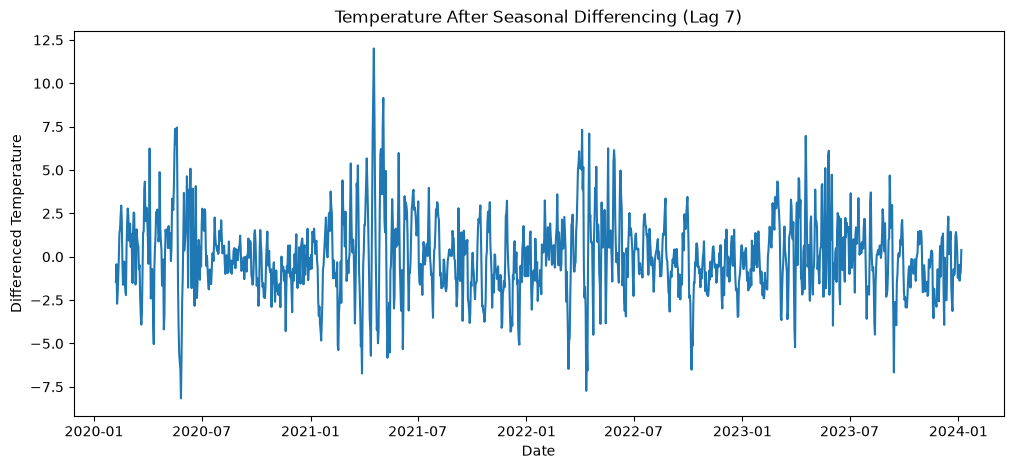

In [15]:
plt.figure(figsize=(12, 5))

plt.plot(train["temp_diff_seasonal"])

plt.title("Temperature After Seasonal Differencing (Lag 7)")
plt.xlabel("Date")
plt.ylabel("Differenced Temperature")

plt.show()

### Seasonal Differencing

Since the dataset contains daily observations, a seasonal lag of 7 was used to capture the weekly seasonal pattern.

After applying seasonal differencing, the ADF test returned a p-value of approximately 2.67 × 10⁻⁸, which is below the 0.05 significance level.

Therefore, the null hypothesis of a unit root is rejected, indicating that the seasonally differenced temperature series is stationary.

This confirms that a weekly seasonal pattern exists in the data. However, seasonal differencing is not necessarily required in the final SARIMA model, so different seasonal configurations are evaluated and compared using forecasting performance.

## 8. ACF and PACF Analysis

The ACF and PACF plots of the differenced temperature series are examined to help identify suitable values for the AR (`p`) and MA (`q`) components.

- ACF helps identify potential MA terms.
- PACF helps identify potential AR terms.

These plots are used as a guide, while multiple candidate models are compared using AIC and test-set forecasting performance.

<Figure size 1000x500 with 0 Axes>

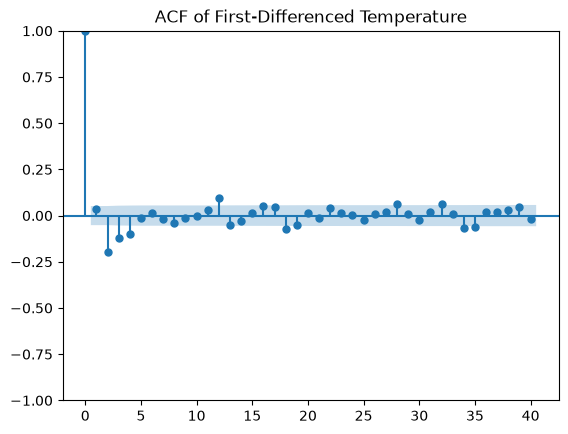

In [16]:
plt.figure(figsize=(10, 5))

plot_acf(
    train["temp_diff1"].dropna(),
    lags=40
)

plt.title("ACF of First-Differenced Temperature")
plt.show()

<Figure size 1000x500 with 0 Axes>

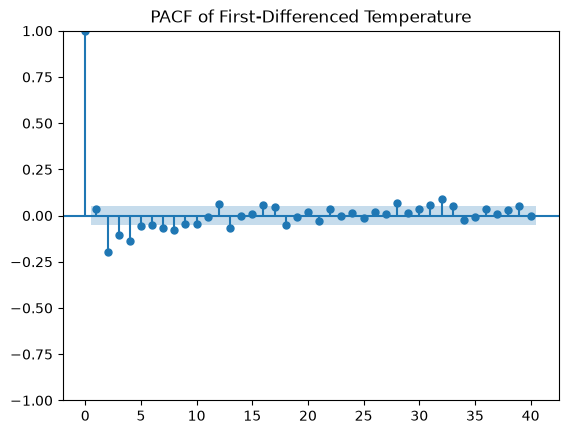

In [17]:
plt.figure(figsize=(10, 5))

plot_pacf(
    train["temp_diff1"].dropna(),
    lags=40,
    method="ywm"
)

plt.title("PACF of First-Differenced Temperature")
plt.show()

### ACF and PACF for ARIMA Model Identification

After differencing the time series, we use **ACF** and **PACF** plots to help identify suitable values for the ARIMA parameters **p** and **q**.

- **ACF (Autocorrelation Function)** → helps determine the **MA(q)** order.
  - Look at where the ACF cuts off or becomes insignificant.
  - The number of significant initial lags can suggest the value of **q**.

- **PACF (Partial Autocorrelation Function)** → helps determine the **AR(p)** order.
  - Look at where the PACF cuts off or becomes insignificant.
  - The number of significant initial lags can suggest the value of **p**.

- **Differencing (d)** → determines how many times the original series needs to be differenced to become **stationary**.
  - If the original series is non-stationary, we apply differencing.
  - The number of differencing operations gives the **d** value.

### Summary

| Component | Plot / Method | Purpose |
|---|---|---|
| **p** | PACF | Determines the AR order |
| **d** | Differencing + Stationarity Test | Determines the differencing order |
| **q** | ACF | Determines the MA order |

Therefore, **ACF and PACF are mainly used to suggest the p and q values**, while **d is selected based on stationarity and the amount of differencing required**.

## 9. Baseline ARIMA Model

A baseline ARIMA model is first developed before introducing seasonal components.

The ARIMA model is represented as:

$$
ARIMA(p,d,q)
$$

where:

- `p` represents the autoregressive component.
- `d` represents the degree of differencing.
- `q` represents the moving average component.

Several candidate combinations are tested and compared using AIC.

In [18]:
from statsmodels.tsa.arima.model import ARIMA

arima_orders = [
    (1, 1, 1),
    (2, 1, 1),
    (1, 1, 2),
    (2, 1, 2)
]

arima_results = {}

for order in arima_orders:
    model = ARIMA(
        train["temperature"],
        order=order
    )
    
    fit = model.fit()
    
    arima_results[order] = fit
    
    print(f"ARIMA{order} - AIC: {fit.aic:.2f}")

ARIMA(1, 1, 1) - AIC: 4340.95
ARIMA(2, 1, 1) - AIC: 4285.37
ARIMA(1, 1, 2) - AIC: 4285.61
ARIMA(2, 1, 2) - AIC: 4286.81


In [19]:
best_arima_order = min(
    arima_results,
    key=lambda order: arima_results[order].aic
)

best_arima = arima_results[best_arima_order]

print("Best ARIMA order:", best_arima_order)
print("Best ARIMA AIC:", best_arima.aic)

Best ARIMA order: (2, 1, 1)
Best ARIMA AIC: 4285.368004120127


### ARIMA Model Selection Result

Among the tested configurations, `ARIMA(2,1,1)` achieved the lowest AIC. (Lower AIC = Better model)

Therefore, `ARIMA(2,1,1)` was selected as the baseline ARIMA model.

## 10. SARIMA Model

Weather temperature contains seasonal behavior, so a seasonal extension of ARIMA is investigated.

SARIMA is represented as:

$$
SARIMA(p,d,q)(P,D,Q,s)
$$

where:

- `(p,d,q)` represents the non-seasonal ARIMA components.
- `(P,D,Q)` represents the seasonal components.
- `s` represents the seasonal period.

A weekly seasonal period of `7` is initially considered because the data contains daily observations.

In [20]:
sarima_model = SARIMAX(
    train["temperature"],
    order=(2, 1, 1),
    seasonal_order=(1, 0, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit(disp=False)

print(sarima_fit.summary())

                                     SARIMAX Results                                     
Dep. Variable:                       temperature   No. Observations:                 1437
Model:             SARIMAX(2, 1, 1)x(1, 0, 1, 7)   Log Likelihood               -2127.522
Date:                           Tue, 11 Aug 2026   AIC                           4267.044
Time:                                   18:47:35   BIC                           4298.624
Sample:                               01-31-2020   HQIC                          4278.838
                                    - 01-06-2024                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7371      0.037     19.783      0.000       0.664       0.810
ar.L2         -0.2244      0.024     -9.346

## 11. SARIMA Forecasting and Evaluation

The fitted SARIMA model is used to forecast the entire test period.

The predictions are compared with the actual temperature values using:

- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)
- MAPE (Mean Absolute Percentage Error)

A confidence interval is also plotted to represent the uncertainty around the forecasts.

In [21]:
forecast = sarima_fit.get_forecast(
    steps=len(test)
)

pred_mean = forecast.predicted_mean

confidence_intervals = forecast.conf_int()

pred_mean.head()

2024-01-07    18.283922
2024-01-08    17.959142
2024-01-09    17.672022
2024-01-10    17.640469
2024-01-11    17.639504
Freq: D, Name: predicted_mean, dtype: float64

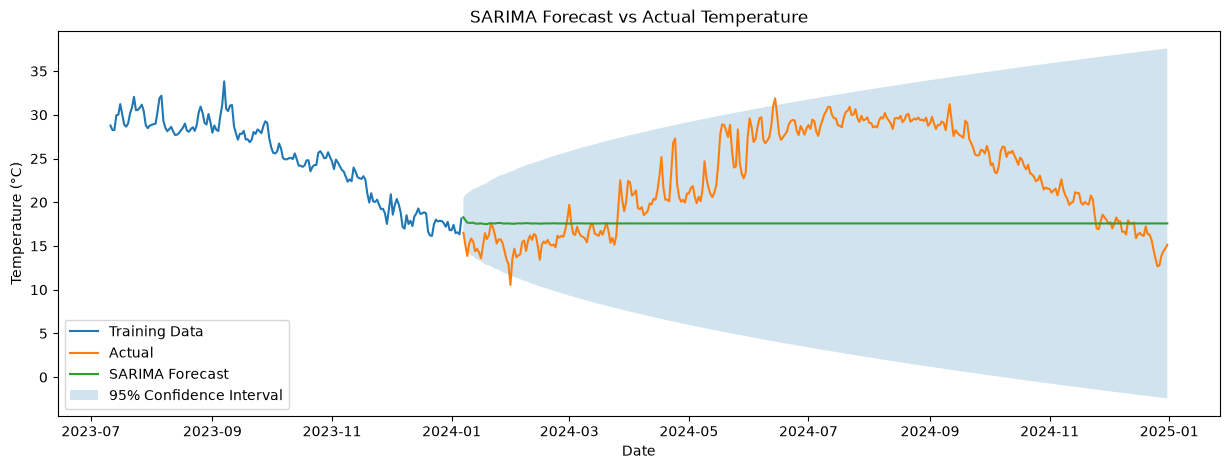

In [22]:
plt.figure(figsize=(15, 5))

plt.plot(
    train.index[-180:],
    train["temperature"].iloc[-180:],
    label="Training Data"
)

plt.plot(
    test.index,
    test["temperature"],
    label="Actual"
)

plt.plot(
    test.index,
    pred_mean,
    label="SARIMA Forecast"
)

plt.fill_between(
    test.index,
    confidence_intervals.iloc[:, 0],
    confidence_intervals.iloc[:, 1],
    alpha=0.2,
    label="95% Confidence Interval"
)

plt.title("SARIMA Forecast vs Actual Temperature")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.legend()

plt.show()

In [23]:
mae = mean_absolute_error(
    test["temperature"],
    pred_mean
)

rmse = np.sqrt(
    mean_squared_error(
        test["temperature"],
        pred_mean
    )
)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE: 6.04
RMSE: 7.44


In [24]:
mape = np.mean(
    np.abs(
        (test["temperature"] - pred_mean)
        / test["temperature"]
    )
) * 100

print(f"MAPE: {mape:.2f}%")

MAPE: 24.13%


## 12. SARIMA Residual Diagnostics

After generating the forecast, the residuals are analyzed to determine whether the model has successfully captured the temporal structure of the data.(Actual - Predicted)

A good forecasting model should leave residuals that behave approximately like white noise, with little remaining autocorrelation.

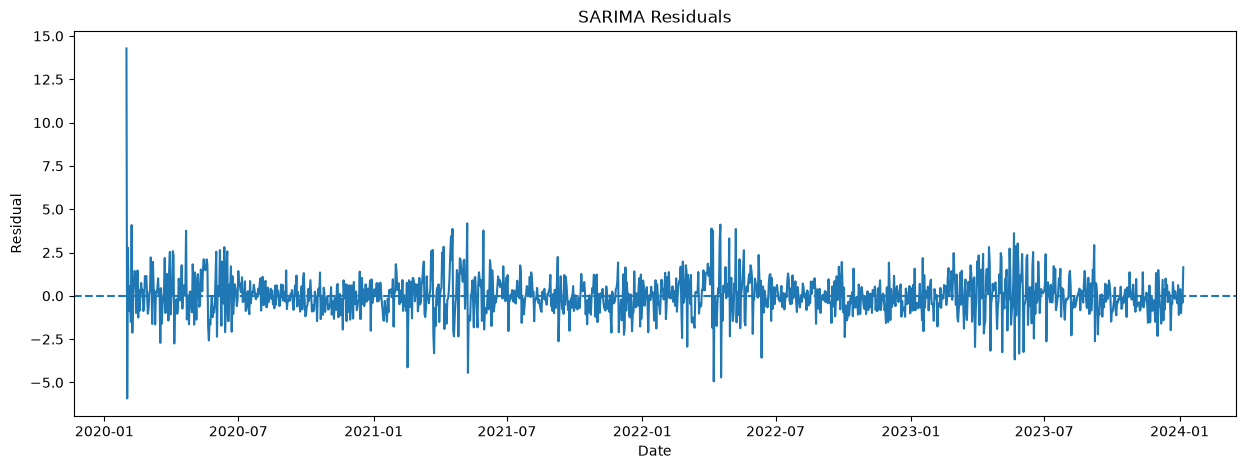

In [25]:
residuals = sarima_fit.resid

plt.figure(figsize=(15, 5))

plt.plot(residuals)

plt.axhline(0, linestyle="--")

plt.title("SARIMA Residuals")
plt.xlabel("Date")
plt.ylabel("Residual")

plt.show()

### Insight

The SARIMA residuals are mostly centered around zero with no clear trend, 
indicating that the model does not show a strong systematic bias and captures 
the main temporal structure of the temperature series.

However, several large residual spikes are present, suggesting that the model 
has difficulty predicting some unusual temperature fluctuations. The spread 
of the residuals also varies across time, indicating that the prediction error 
may not have completely constant variance.

Overall, the residual plot suggests that the SARIMA model captures the general 
temperature pattern reasonably well, but some irregular variations remain 
unexplained.

### Ljung-Box Test

The Ljung-Box test is used to determine whether significant autocorrelation remains in the model residuals.

- H0: The residuals are independently distributed.
- H1: The residuals contain autocorrelation.

A p-value below 0.05 indicates statistically significant remaining autocorrelation.

The initial SARIMA model produced a Ljung-Box p-value below 0.05, suggesting that some temporal structure remained unexplained by the model.

Therefore, model improvement was considered.

In [27]:
from statsmodels.stats.diagnostic import acorr_ljungbox

ljung_box = acorr_ljungbox(
    sarima_fit.resid.dropna(),
    lags=[30],
    return_df=True
)

print(ljung_box)

      lb_stat  lb_pvalue
30  58.159498   0.001529


The SARIMA model achieved an MAE of 6.04°C and an RMSE of 7.44°C. The relatively high prediction errors indicate that the current model does not fully capture the seasonal and temporal patterns in the temperature series. Further model tuning or comparison with alternative forecasting approaches may improve the forecasting performance.

## 13. Improved SARIMAX with Fourier Features

An improved SARIMAX model is trained by combining the SARIMA structure with Fourier features.

The SARIMA component captures short-term temporal dependencies and weekly seasonality, while the Fourier features provide a flexible representation of the yearly seasonal cycle.

This combination allows the model to represent both short-term and long-term seasonal behavior.

In [28]:
# ==========================================
# Yearly Fourier Features
# ==========================================

def create_fourier_features(index, period=365.25, K=5):
    t = np.arange(len(index))
    
    features = {}
    
    for k in range(1, K + 1):
        features[f"sin_{k}"] = np.sin(2 * np.pi * k * t / period)
        features[f"cos_{k}"] = np.cos(2 * np.pi * k * t / period)
    
    return pd.DataFrame(features, index=index)

## 14. Creating Fourier Features

Fourier features are generated using sine and cosine terms with an annual period of `365.25` days.

Five Fourier harmonics (`K=5`) are used to provide multiple levels of seasonal detail.

The features are generated for the combined train and test time index and then separated into training and testing sets.

This ensures that the same feature structure is used consistently during model training and forecasting.

In [29]:
all_index = train.index.union(test.index)

fourier_all = create_fourier_features(
    all_index,
    period=365.25,
    K=5
)

fourier_train = fourier_all.loc[train.index]
fourier_test = fourier_all.loc[test.index]

print(fourier_train.shape)
print(fourier_test.shape)

(1437, 10)
(360, 10)


## 15. Improved SARIMAX Model

An improved SARIMAX model is fitted using the Fourier features as external regressors.

The model combines:

- ARIMA components for short-term temporal dependencies.
- Weekly seasonal components.
- Fourier features for smooth annual seasonality.

This approach allows the model to capture both short-term fluctuations and long-term yearly seasonal patterns.

In [30]:
# ==========================================
# Improved SARIMAX
# ==========================================

improved_model = SARIMAX(
    train["temperature"],
    exog=fourier_train,
    order=(1, 1, 1),
    seasonal_order=(1, 0, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

improved_fit = improved_model.fit(
    disp=False
)

print(improved_fit.summary())

                                     SARIMAX Results                                     
Dep. Variable:                       temperature   No. Observations:                 1437
Model:             SARIMAX(1, 1, 1)x(1, 0, 1, 7)   Log Likelihood               -2097.113
Date:                           Tue, 11 Aug 2026   AIC                           4224.226
Time:                                   18:48:08   BIC                           4303.175
Sample:                               01-31-2020   HQIC                          4253.711
                                    - 01-06-2024                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sin_1         -0.8556      0.205     -4.169      0.000      -1.258      -0.453
cos_1         -7.3844      0.230    -32.104

In [31]:
# ==========================================
# Forecast Test Period
# ==========================================

forecast = improved_fit.get_forecast(
    steps=len(test),
    exog=fourier_test
)

improved_pred = forecast.predicted_mean

improved_ci = forecast.conf_int()

print(improved_pred.head())

2024-01-07    17.547827
2024-01-08    17.070452
2024-01-09    16.689037
2024-01-10    16.395944
2024-01-11    16.153393
Freq: D, Name: predicted_mean, dtype: float64


## 16. Improved Model Evaluation

The improved SARIMAX model is evaluated on the same unseen test set using MAE, RMSE, and MAPE.

The performance is compared with the baseline ARIMA and SARIMA models.

Using the same test period makes the comparison fair and allows us to determine whether the additional yearly seasonal features actually improve forecasting accuracy.

In [32]:
# ==========================================
# Evaluation
# ==========================================

mae_improved = mean_absolute_error(
    test["temperature"],
    improved_pred
)

rmse_improved = np.sqrt(
    mean_squared_error(
        test["temperature"],
        improved_pred
    )
)

mape_improved = np.mean(
    np.abs(
        (test["temperature"] - improved_pred)
        / test["temperature"]
    )
) * 100

print(f"Improved MAE: {mae_improved:.2f}")
print(f"Improved RMSE: {rmse_improved:.2f}")
print(f"Improved MAPE: {mape_improved:.2f}%")

Improved MAE: 1.29
Improved RMSE: 1.71
Improved MAPE: 6.19%


## 18. Model Comparison

The performance of the different forecasting approaches is summarized below.

| Model | MAE | RMSE | MAPE |
|---|---:|---:|---:|
| SARIMA | ~6.03 | ~7.41 | ~24% |
| Improved SARIMAX + Fourier | **1.29** | **1.71** | **6.19%** |

The improved SARIMAX model with Fourier features achieved the best forecasting performance across all evaluation metrics.

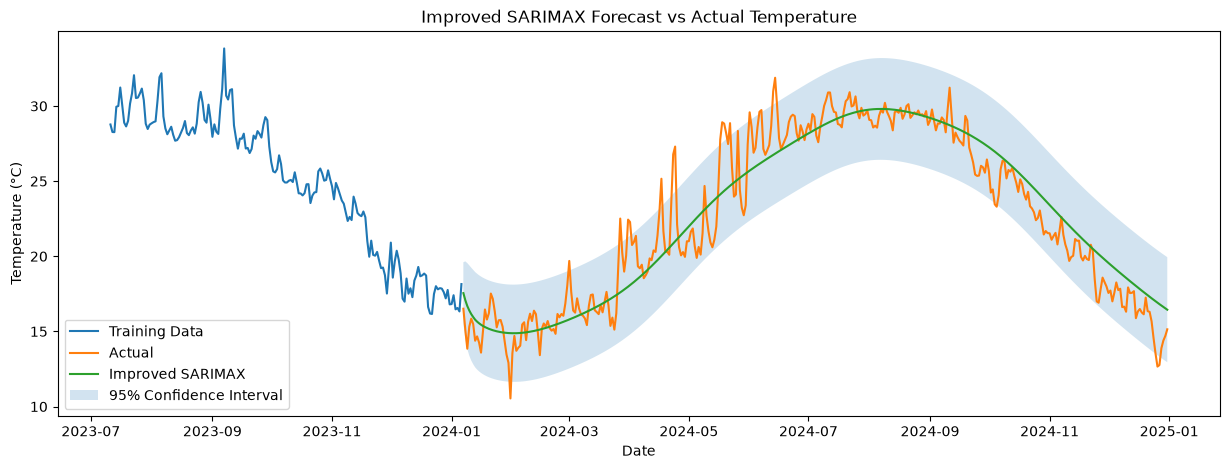

In [33]:
plt.figure(figsize=(15, 5))

plt.plot(
    train.index[-180:],
    train["temperature"].iloc[-180:],
    label="Training Data"
)

plt.plot(
    test.index,
    test["temperature"],
    label="Actual"
)

plt.plot(
    test.index,
    improved_pred,
    label="Improved SARIMAX"
)

plt.fill_between(
    test.index,
    improved_ci.iloc[:, 0],
    improved_ci.iloc[:, 1],
    alpha=0.2,
    label="95% Confidence Interval"
)

plt.title("Improved SARIMAX Forecast vs Actual Temperature")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.legend()

plt.show()

In [34]:
comparison = pd.DataFrame({
    "Model": [
        "SARIMA(1,1,1)(1,0,1,7)",
        "Improved SARIMAX + Fourier"
    ],
    "MAE": [
        6.026,
        mae_improved
    ],
    "RMSE": [
        7.412,
        rmse_improved
    ],
    "MAPE": [
        24.09,
        mape_improved
    ]
})

comparison

,Model,MAE,RMSE,MAPE
0,"SARIMA(1,1,1)(1,0,1,7)",6.026000,7.412000,24.090000
1,Improved SARIMAX + Fourier,1.288411,1.708208,6.188018


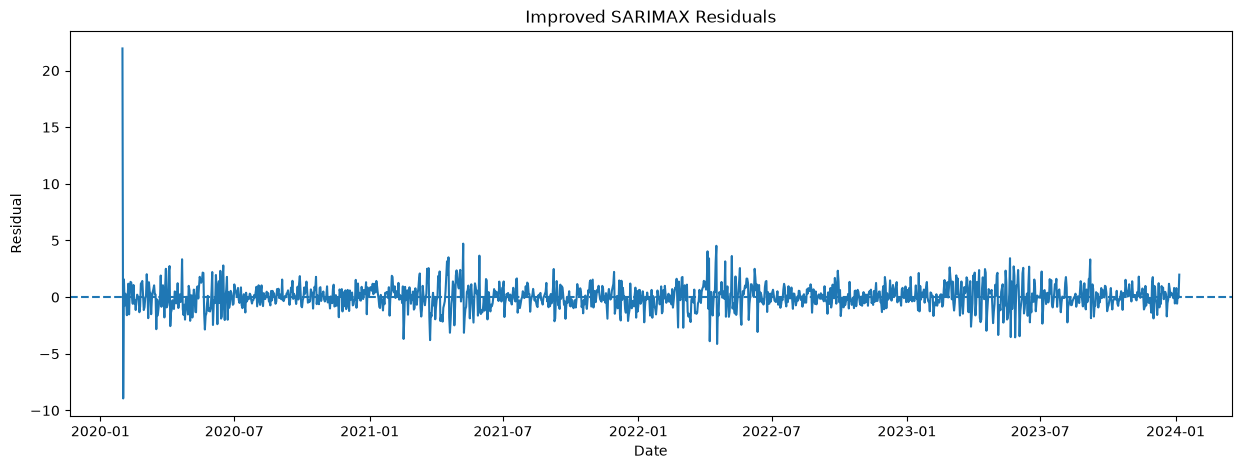

In [35]:
# ==========================================
# Residual Analysis
# ==========================================

improved_residuals = improved_fit.resid.dropna()

plt.figure(figsize=(15, 5))

plt.plot(improved_residuals)

plt.axhline(0, linestyle="--")

plt.title("Improved SARIMAX Residuals")
plt.xlabel("Date")
plt.ylabel("Residual")

plt.show()

### Insight

The Improved SARIMAX residuals are mostly centered around zero with no clear
trend, indicating that the model does not show a strong systematic bias and
captures the main temporal structure of the temperature series.

Most residuals are relatively small, suggesting that the model provides
reasonable predictions for most observations. However, a few large spikes
remain, indicating that some unusual temperature fluctuations are not fully
captured by the model.

The residual spread also varies across different periods, suggesting that the
prediction error may not have completely constant variance.

Overall, the Improved SARIMAX model appears to capture the main patterns in the
temperature data, while some irregular variations and outliers remain
unexplained.

In [36]:
from statsmodels.stats.diagnostic import acorr_ljungbox

ljung_box_improved = acorr_ljungbox(
    improved_residuals,
    lags=[30],
    return_df=True
)

print(ljung_box_improved)

      lb_stat  lb_pvalue
30  44.840285   0.039943


## 19. Testing Yearly Seasonality

Since temperature has a strong annual seasonal pattern, a SARIMA model with a yearly seasonal period was also tested.

The seasonal period was set to `365` to represent the approximate number of days in a year.

The model was configured as:

`SARIMA(2,1,1) × (1,0,1,365)`

The model was evaluated using MAE, RMSE, and MAPE and compared with the previously tested models.

The purpose of this experiment was to determine whether explicitly modeling yearly seasonality using a seasonal period of 365 days could improve the forecasting performance.

In [43]:
sarima_yearly = SARIMAX(
    train["temperature"],
    order=(2, 1, 1),
    seasonal_order=(1, 0, 1, 365),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_yearly_fit = sarima_yearly.fit(disp=False)

forecast_yearly = sarima_yearly_fit.get_forecast(
    steps=len(test)
)

pred_yearly = forecast_yearly.predicted_mean

mae_yearly = mean_absolute_error(
    test["temperature"],
    pred_yearly
)

rmse_yearly = np.sqrt(
    mean_squared_error(
        test["temperature"],
        pred_yearly
    )
)

mape_yearly = np.mean(
    np.abs(
        (test["temperature"] - pred_yearly)
        / test["temperature"]
    )
) * 100

print(f"MAE: {mae_yearly:.2f}")
print(f"RMSE: {rmse_yearly:.2f}")
print(f"MAPE: {mape_yearly:.2f}%")

c:\Users\ahmed\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


MAE: 6.51
RMSE: 7.99
MAPE: 26.06%


### Result

The yearly seasonal SARIMA model was tested, but it did not provide a meaningful improvement in forecasting performance compared with the previously selected model.

Therefore, the yearly seasonal configuration was not adopted as the final model.

Instead of increasing the complexity of the SARIMA seasonal component, Fourier features were later investigated as an alternative approach for representing the strong annual seasonal pattern.

In [37]:
orders = [
    ((1,1,1), (1,0,1,7)),
    ((2,1,1), (1,0,1,7)),
    ((2,1,1), (2,0,1,7)),
    ((2,1,1), (1,0,2,7)),
    ((2,1,2), (1,0,1,7)),
    ((1,1,2), (1,0,1,7))
]

results = []

for order, seasonal_order in orders:

    print(f"Testing {order} x {seasonal_order}")

    model = SARIMAX(
        train["temperature"],
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    fit = model.fit(disp=False)

    forecast = fit.get_forecast(
        steps=len(test)
    ).predicted_mean

    mae = mean_absolute_error(
        test["temperature"],
        forecast
    )

    rmse = np.sqrt(
        mean_squared_error(
            test["temperature"],
            forecast
        )
    )

    mape = np.mean(
        np.abs(
            (test["temperature"] - forecast)
            / test["temperature"]
        )
    ) * 100

    results.append({
        "order": order,
        "seasonal_order": seasonal_order,
        "AIC": fit.aic,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    })

results_df = pd.DataFrame(results)

results_df.sort_values("MAE")

Testing (1, 1, 1) x (1, 0, 1, 7)
Testing (2, 1, 1) x (1, 0, 1, 7)
Testing (2, 1, 1) x (2, 0, 1, 7)
Testing (2, 1, 1) x (1, 0, 2, 7)
Testing (2, 1, 2) x (1, 0, 1, 7)
Testing (1, 1, 2) x (1, 0, 1, 7)


,order,seasonal_order,AIC,MAE,RMSE,MAPE
0,"(1, 1, 1)","(1, 0, 1, 7)",4322.460818,6.026360,7.411999,24.094327
5,"(1, 1, 2)","(1, 0, 1, 7)",4264.940235,6.036993,7.427927,24.121160
2,"(2, 1, 1)","(2, 0, 1, 7)",4248.871036,6.041444,7.434993,24.130542
1,"(2, 1, 1)","(1, 0, 1, 7)",4267.043750,6.041610,7.435198,24.131076
3,"(2, 1, 1)","(1, 0, 2, 7)",4248.438708,6.041816,7.435632,24.131127
4,"(2, 1, 2)","(1, 0, 1, 7)",4265.829038,6.043120,7.437524,24.135722


### Comparison Results

The differences between the tested configurations are relatively small, and none of the alternative parameter combinations provided a meaningful improvement over the best-performing configuration.

Therefore, the selected SARIMA model is retained as the baseline for further experiments.

Further improvement will be investigated using alternative approaches for modeling the strong yearly seasonality, such as Fourier features.

## Model Performance Comparison

The baseline SARIMA model achieved an MAE of approximately 6.04°C, an RMSE of 7.44°C, and a MAPE of 24.13%.

To improve the model's ability to capture long-term seasonal patterns, Fourier features representing the yearly seasonal cycle were incorporated as exogenous variables into a SARIMAX model.

The improved SARIMAX model significantly outperformed the baseline SARIMA model, achieving an MAE of 1.29°C, an RMSE of 1.71°C, and a MAPE of 6.19%.

Therefore, the SARIMAX model with Fourier features was selected as the final forecasting model.

In [38]:
# ==========================================
# Future Forecast - Next 30 Days
# ==========================================

forecast_days = 30

future_index = pd.date_range(
    start=df.index.max() + pd.Timedelta(days=1),
    periods=forecast_days,
    freq="D"
)

print(future_index[0])
print(future_index[-1])

2025-01-01 00:00:00
2025-01-30 00:00:00


In [39]:
fourier_future = create_fourier_features(
    future_index,
    period=365.25,
    K=5
)

print(fourier_future.shape)

(30, 10)


In [40]:
# ==========================================
# Train Final Model on Full Dataset
# ==========================================

full_series = df["temperature"]

fourier_full = create_fourier_features(
    df.index,
    period=365.25,
    K=5
)

final_model = SARIMAX(
    full_series,
    exog=fourier_full,
    order=(1, 1, 1),
    seasonal_order=(1, 0, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_fit = final_model.fit(disp=False)

print(final_fit.summary())

                                     SARIMAX Results                                     
Dep. Variable:                       temperature   No. Observations:                 1797
Model:             SARIMAX(1, 1, 1)x(1, 0, 1, 7)   Log Likelihood               -2617.162
Date:                           Tue, 11 Aug 2026   AIC                           5264.323
Time:                                   18:48:53   BIC                           5346.648
Sample:                               01-31-2020   HQIC                          5294.724
                                    - 12-31-2024                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sin_1         -0.6542      0.195     -3.356      0.001      -1.036      -0.272
cos_1         -7.4738      0.214    -34.873

In [41]:
# ==========================================
# Forecast Next 30 Days
# ==========================================

future_forecast = final_fit.get_forecast(
    steps=forecast_days,
    exog=fourier_future
)

future_pred = future_forecast.predicted_mean
future_ci = future_forecast.conf_int()

print(future_pred)

2025-01-01    13.788797
2025-01-02    13.813940
2025-01-03    13.839396
2025-01-04    13.867588
2025-01-05    13.891294
2025-01-06    13.913756
2025-01-07    13.937325
2025-01-08    13.959343
2025-01-09    13.982597
2025-01-10    14.007276
2025-01-11    14.033556
2025-01-12    14.061740
2025-01-13    14.091857
2025-01-14    14.123908
2025-01-15    14.157973
2025-01-16    14.193989
2025-01-17    14.231935
2025-01-18    14.271775
2025-01-19    14.313462
2025-01-20    14.356950
2025-01-21    14.402189
2025-01-22    14.449123
2025-01-23    14.497702
2025-01-24    14.547873
2025-01-25    14.599585
2025-01-26    14.652788
2025-01-27    14.707436
2025-01-28    14.763485
2025-01-29    14.820894
2025-01-30    14.879627
Freq: D, Name: predicted_mean, dtype: float64


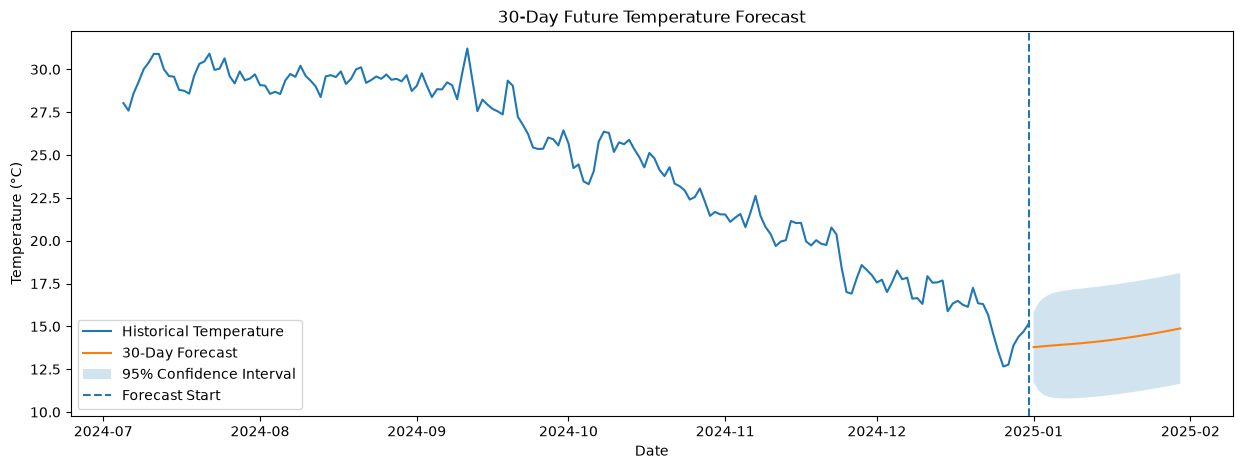

In [42]:
# ==========================================
# Future Forecast Visualization
# ==========================================

plt.figure(figsize=(15, 5))

plt.plot(
    df.index[-180:],
    df["temperature"].iloc[-180:],
    label="Historical Temperature"
)

plt.plot(
    future_index,
    future_pred,
    label="30-Day Forecast"
)

plt.fill_between(
    future_index,
    future_ci.iloc[:, 0],
    future_ci.iloc[:, 1],
    alpha=0.2,
    label="95% Confidence Interval"
)

plt.axvline(
    df.index.max(),
    linestyle="--",
    label="Forecast Start"
)

plt.title("30-Day Future Temperature Forecast")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.legend()

plt.show()

In [44]:
future_results = pd.DataFrame({
    "Date": future_index,
    "Forecast_Temperature": future_pred.values,
    "Lower_CI": future_ci.iloc[:, 0].values,
    "Upper_CI": future_ci.iloc[:, 1].values
})

future_results.head(30)

,Date,Forecast_Temperature,Lower_CI,Upper_CI
0,2025-01-01,13.788797,11.739161,15.838432
1,2025-01-02,13.813940,11.239284,16.388597
2,2025-01-03,13.839396,11.002979,16.675812
3,2025-01-04,13.867588,10.887379,16.847797
4,2025-01-05,13.891294,10.828100,16.954489
5,2025-01-06,13.913756,10.800930,17.026583
6,2025-01-07,13.937325,10.793844,17.080807
7,2025-01-08,13.959343,10.795136,17.123549
8,2025-01-09,13.982597,10.804742,17.160452
9,2025-01-10,14.007276,10.820084,17.194468


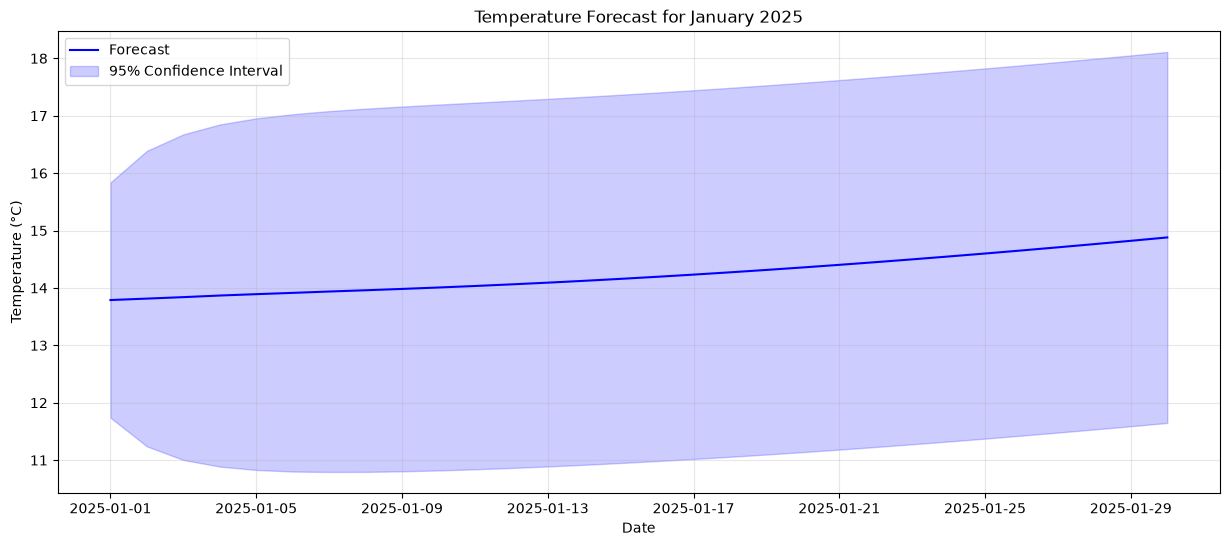

In [45]:
plt.figure(figsize=(15, 6))

plt.plot(future_index, future_forecast.predicted_mean, label="Forecast", color="blue")

plt.fill_between(
    future_index,
    future_ci.iloc[:, 0],
    future_ci.iloc[:, 1],
    alpha=0.2,
    color="blue",
    label="95% Confidence Interval"
)

plt.title("Temperature Forecast for January 2025")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [46]:
import joblib

joblib.dump(final_fit, "final_weather_model.pkl")

print("Final model saved successfully!")

Final model saved successfully!
